In [2]:
pip install scikit-learn pandas numpy matplotlib seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---------------- ----------------------- 122.9/294.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\zaini\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100


In [4]:
df = pd.read_csv('student-mat.csv', sep=';')

# Confirming if it loaded correctly
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# Initial exploration
# check data types, missing values, and basic stats

print("Column Names")
print(df.columns.tolist())

print("\n Data Types")
print(df.dtypes)

print("\n Missing Values")
print(df.isnull().sum())

print("\n Basic Statistics (numeric columns)")
df.describe()

Column Names
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

 Data Types
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
# Create target variable
# at_risk = 1 if final grade is below 10
# at_risk = 0 otherwise
df['at_risk'] = (df['G3'] < 10).astype(int)

print("Target variable distribution:")
print(df['at_risk'].value_counts())

print("\nAs percentages:")
print(df['at_risk'].value_counts(normalize=True).round(3) * 100)

Target variable distribution:
at_risk
0    265
1    130
Name: count, dtype: int64

As percentages:
at_risk
0    67.1
1    32.9
Name: proportion, dtype: float64


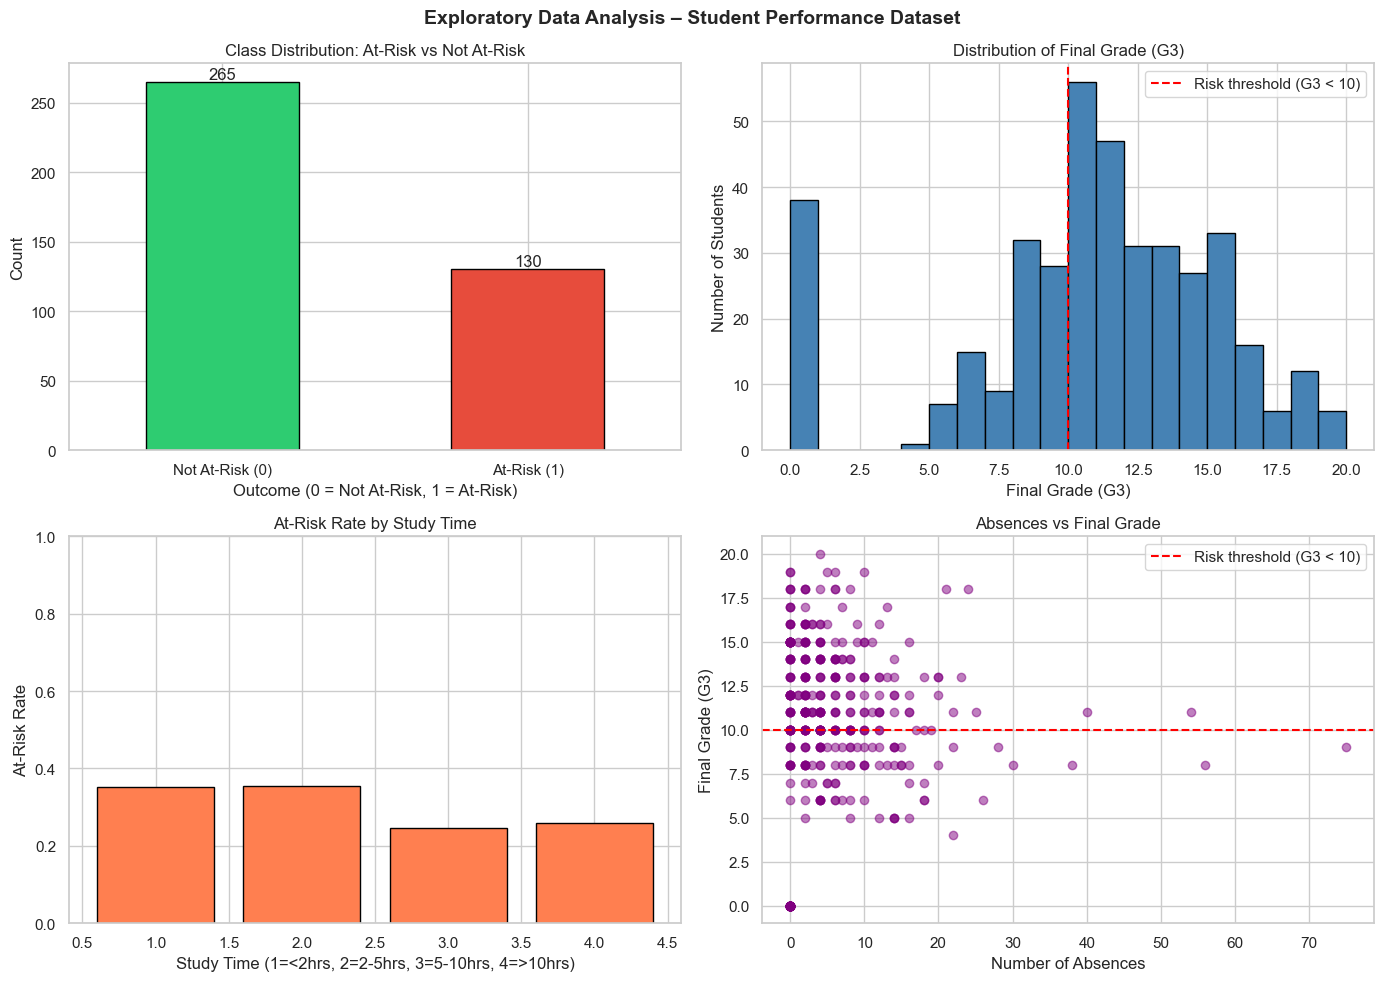

EDA plots saved.


In [10]:
# Exploratory Data Analysis
# visualize the distribution of key variables
# and their relationship to the at-risk outcome

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis – Student Performance Dataset',
             fontsize=14, fontweight='bold')

# Plot 1: Class distribution (at-risk vs not at-risk)
ax1 = axes[0, 0]

risk_counts = df['at_risk'].value_counts().sort_index()  # ensures 0 then 1
risk_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black')

ax1.set_title('Class Distribution: At-Risk vs Not At-Risk')
ax1.set_xlabel('Outcome (0 = Not At-Risk, 1 = At-Risk)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Not At-Risk (0)', 'At-Risk (1)'], rotation=0)

for p in ax1.patches:
    ax1.annotate(str(int(p.get_height())),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')

# Plot 2: Final grade (G3) distribution
ax2 = axes[0, 1]
ax2.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
ax2.axvline(x=10, color='red', linestyle='--', label='Risk threshold (G3 < 10)')
ax2.set_title('Distribution of Final Grade (G3)')
ax2.set_xlabel('Final Grade (G3)')
ax2.set_ylabel('Number of Students')
ax2.legend()

# Plot 3: Study time vs at-risk rate
ax3 = axes[1, 0]
study_risk = df.groupby('studytime')['at_risk'].mean().reset_index()
ax3.bar(study_risk['studytime'], study_risk['at_risk'],
        color='coral', edgecolor='black')
ax3.set_title('At-Risk Rate by Study Time')
ax3.set_xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
ax3.set_ylabel('At-Risk Rate')
ax3.set_ylim(0, 1)

# Plot 4: Absences vs final grade
ax4 = axes[1, 1]
ax4.scatter(df['absences'], df['G3'], alpha=0.5, color='purple')
ax4.axhline(y=10, color='red', linestyle='--', label='Risk threshold (G3 < 10)')
ax4.set_title('Absences vs Final Grade')
ax4.set_xlabel('Number of Absences')
ax4.set_ylabel('Final Grade (G3)')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print("EDA plots saved.")

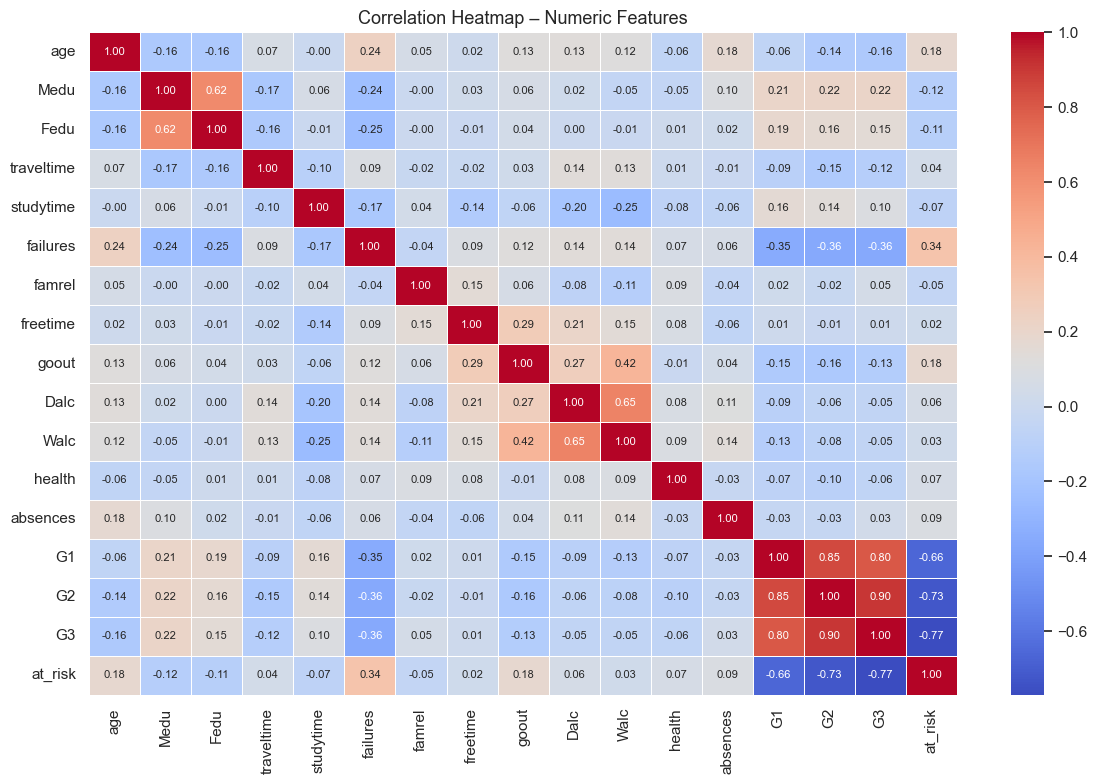


Top correlations with G3 (final grade):
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
at_risk      -0.770042
Name: G3, dtype: float64


In [11]:
# Correlation heatmap (numeric features only)
# To understand which features are most related to the final grade G3

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap – Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Printing the top features most correlated with G3
print("\nTop correlations with G3 (final grade):")
print(corr_matrix['G3'].sort_values(ascending=False).drop('G3'))

In [12]:
# Cell 8: Preprocessing
# Steps:
# 1. Encode all categorical (string) columns using LabelEncoder
# 2. Drop G1, G2, G3 from features 
# 3. Separate features (X) and target (y)

# Working on a copy to preserve the original
data = df.copy()

# Step 1: Encode categorical columns
le = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns being encoded:", categorical_cols)

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Step 2: Drop grade columns and the target column created
# drop G1 and G2 because they directly predict G3 
X = data.drop(columns=['G1', 'G2', 'G3', 'at_risk'])  # Drop the target column from features
y = data['at_risk']

print("\nFeatures used (X):", X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nClass counts in y:")
print(y.value_counts())

Categorical columns being encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Features used (X): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Feature matrix shape: (395, 30)
Target vector shape: (395,)

Class counts in y:
at_risk
0    265
1    130
Name: count, dtype: int64


In [ ]:
# Train/Test Split
# Using 80/20 split with stratify=y to ensure
# the class ratio (pass/fail) is preserved in both
# training and test sets. random_state=42 ensures
# reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set size: (316, 30)
Test set size:     (79, 30)

Class distribution in training set:
at_risk
0    212
1    104
Name: count, dtype: int64

Class distribution in test set:
at_risk
0    53
1    26
Name: count, dtype: int64


In [14]:
# Feature Scaling
# StandardScaler transforms each feature to have mean=0 and std=1. This is required for SVM because
# it is sensitive to feature magnitude.
# We fit the scaler on training data, then transform both train and test 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Mean of first feature in training set (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std  of first feature in training set (should be ~1):", X_train_scaled[:, 0].std().round(4))

Scaling complete.
Mean of first feature in training set (should be ~0): -0.0
Std  of first feature in training set (should be ~1): 1.0


In [15]:
# Random Forest – Baseline
# first train with default parameters to get a baseline performance before tuning.

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_rf_base = rf_baseline.predict(X_test)

print("Random Forest Baseline Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_base):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf_base):.4f}")

Random Forest Baseline Performance
Accuracy:  0.6962
Precision: 0.5714
Recall:    0.3077
F1 Score:  0.4000


In [16]:
# Random Forest – GridSearchCV Tuning
# We search combinations of:
# - n_estimators: number of trees in the forest
# - max_depth: how deep each tree can grow
# - min_samples_split: min samples needed to split a node
# cv=5 means 5-fold cross-validation

rf_param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10, 15],
    'min_samples_split':[2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters Found")
print(rf_grid.best_params_)
print(f"\nBest CV F1 Score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters Found
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

Best CV F1 Score: 0.4042


Random Forest – Final Performance
              precision    recall  f1-score   support

 Not At-Risk       0.74      0.92      0.82        53
     At-Risk       0.69      0.35      0.46        26

    accuracy                           0.73        79
   macro avg       0.72      0.64      0.64        79
weighted avg       0.73      0.73      0.70        79

ROC-AUC Score: 0.7104


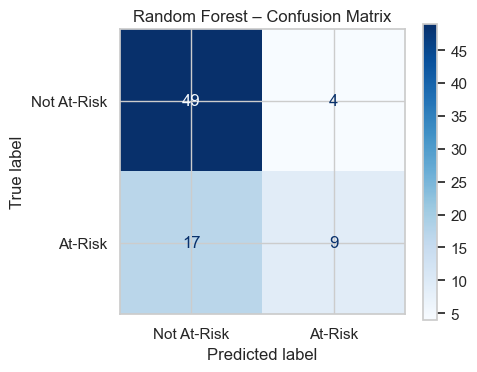

In [25]:
# Random Forest – Final Evaluation

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print("Random Forest – Final Performance")
print(classification_report(y_test, y_pred_rf, target_names=['Not At-Risk', 'At-Risk']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['Not At-Risk', 'At-Risk'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', bbox_inches='tight')
plt.show()

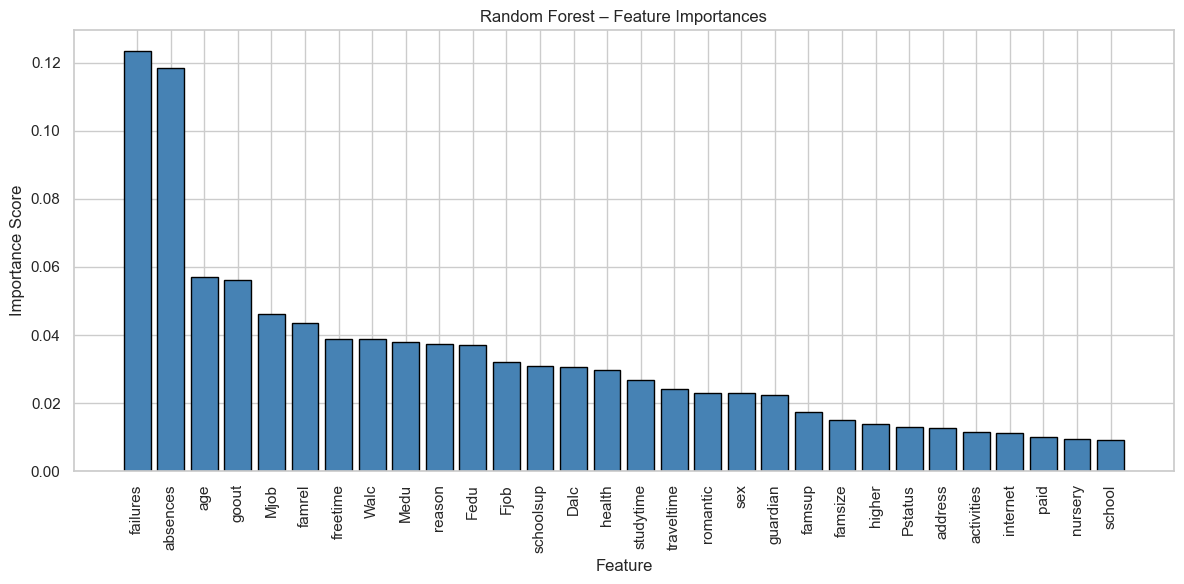


Top 10 most important features:
  failures             0.1233
  absences             0.1186
  age                  0.0571
  goout                0.0561
  Mjob                 0.0460
  famrel               0.0435
  freetime             0.0389
  Walc                 0.0387
  Medu                 0.0378
  reason               0.0374


In [18]:
# Random Forest – Feature Importance
# RF can tell us which features contributed most to its decisions. 

importances = rf_best.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.title('Random Forest – Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 10 most important features:")
for i in range(10):
    print(f"  {feature_names[indices[i]]:<20} {importances[indices[i]]:.4f}")

In [19]:
# SVM – Baseline
# SVM with default parameters and RBF kernel.
# Using the scaled features here (X_train_scaled) because SVM is sensitive to feature magnitude.

svm_baseline = SVC(kernel='rbf', random_state=42, probability=True)
svm_baseline.fit(X_train_scaled, y_train)
y_pred_svm_base = svm_baseline.predict(X_test_scaled)

print("SVM Baseline Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_base):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_svm_base):.4f}")

SVM Baseline Performance
Accuracy:  0.6835
Precision: 0.5556
Recall:    0.1923
F1 Score:  0.2857


In [20]:
# SVM – GridSearchCV Tuning
# C: regularization parameter — higher C = less margin
# gamma: defines how far the influence of a single training example reaches 

svm_param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print("\n Best Parameters Found")
print(svm_grid.best_params_)
print(f"\nBest CV F1 Score: {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best Parameters Found
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best CV F1 Score: 0.4317


SVM – Final Performance
              precision    recall  f1-score   support

 Not At-Risk       0.71      0.77      0.74        53
     At-Risk       0.43      0.35      0.38        26

    accuracy                           0.63        79
   macro avg       0.57      0.56      0.56        79
weighted avg       0.62      0.63      0.62        79

ROC-AUC Score: 0.6923


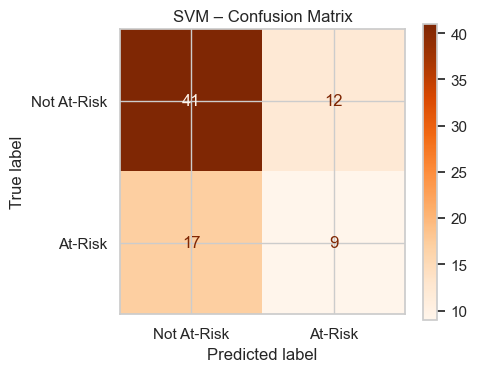

In [26]:
# SVM – Final Evaluation

svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)
y_prob_svm = svm_best.predict_proba(X_test_scaled)[:, 1]

print("SVM – Final Performance")
print(classification_report(y_test, y_pred_svm, target_names=['Not At-Risk', 'At-Risk']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_svm):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=['Not At-Risk', 'At-Risk'],
    cmap='Oranges',
    ax=ax
)
ax.set_title('SVM – Confusion Matrix')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

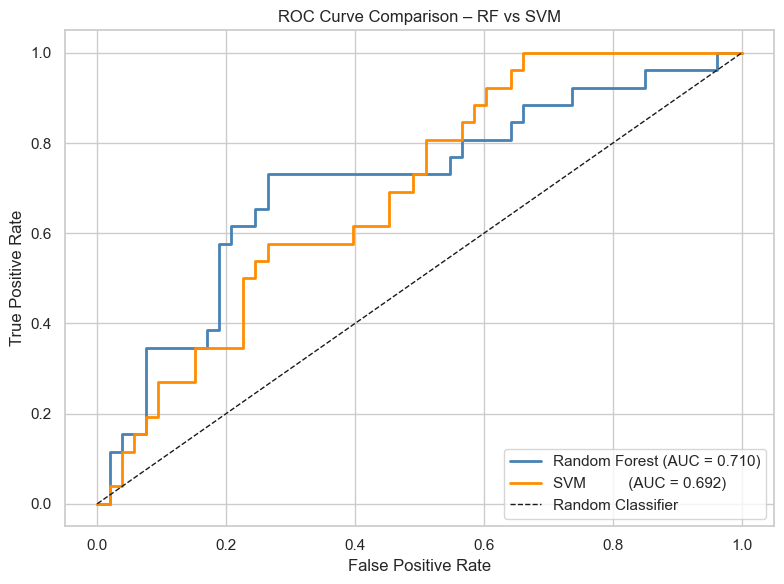

In [22]:
# ROC Curves – RF vs SVM
# ROC curve plots True Positive Rate vs False Positive Rate.
# AUC closer to 1.0 = better model

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_rf  = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {auc_rf:.3f})',  color='steelblue', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM          (AUC = {auc_svm:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison – RF vs SVM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

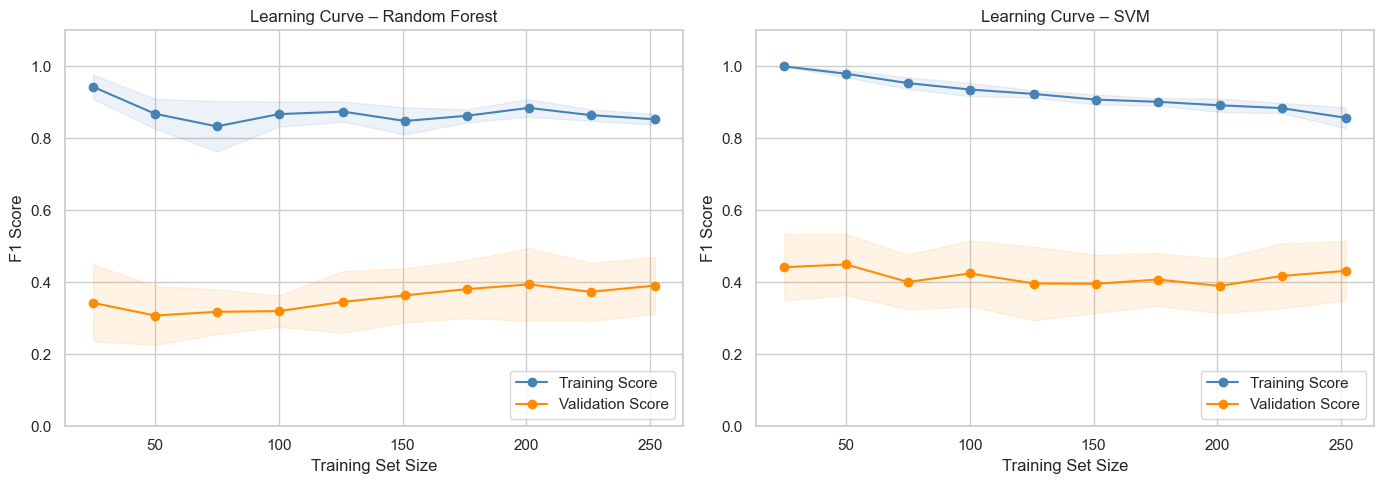

In [23]:
# Learning Curves
# Learning curves show how each model improves as more training data is added. They help diagnose
# underfitting vs overfitting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, X_data, title in zip(
    axes,
    [rf_best, svm_best],
    [X_train, X_train_scaled],
    ['Random Forest', 'SVM']
):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_data, y_train,
        cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Score')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation Score')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='darkorange')
    ax.set_title(f'Learning Curve – {title}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()

In [24]:
# Side-by-side comparison of both models

results = {
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Random Forest': [
        round(accuracy_score(y_test,  y_pred_rf),  4),
        round(precision_score(y_test, y_pred_rf),  4),
        round(recall_score(y_test,    y_pred_rf),  4),
        round(f1_score(y_test,        y_pred_rf),  4),
        round(roc_auc_score(y_test,   y_prob_rf),  4)
    ],
    'SVM': [
        round(accuracy_score(y_test,  y_pred_svm),  4),
        round(precision_score(y_test, y_pred_svm),  4),
        round(recall_score(y_test,    y_pred_svm),  4),
        round(f1_score(y_test,        y_pred_svm),  4),
        round(roc_auc_score(y_test,   y_prob_svm),  4)
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Metric')
print(" Final Model Comparison")
print(comparison_df.to_string())

 Final Model Comparison
           Random Forest     SVM
Metric                          
Accuracy          0.7342  0.6329
Precision         0.6923  0.4286
Recall            0.3462  0.3462
F1 Score          0.4615  0.3830
ROC-AUC           0.7104  0.6923


In [25]:
# Cross-Validation (5-fold) for both models
# CV gives a more reliable estimate of performance than a single train/test split, especially on a small dataset like this one

rf_cv_scores  = cross_val_score(rf_best,  X,        y, cv=5, scoring='f1')
svm_cv_scores = cross_val_score(svm_best, scaler.fit_transform(X), y, cv=5, scoring='f1')

print(" 5-Fold Cross-Validation F1 Scores")
print(f"Random Forest: {rf_cv_scores.round(4)}  →  Mean: {rf_cv_scores.mean():.4f}  Std: {rf_cv_scores.std():.4f}")
print(f"SVM:           {svm_cv_scores.round(4)}  →  Mean: {svm_cv_scores.mean():.4f}  Std: {svm_cv_scores.std():.4f}")

 5-Fold Cross-Validation F1 Scores
Random Forest: [0.8095 0.8421 0.7805 0.7826 0.7273]  →  Mean: 0.7884  Std: 0.0379
SVM:           [0.8217 0.843  0.784  0.8281 0.7967]  →  Mean: 0.8147  Std: 0.0214


In [ ]:
## Summary

# Both Random Forest and SVM were implemented and evaluated on the UCI Student Performance dataset.
# After hyperparameter tuning using GridSearchCV, the results above show that Random Forest performed better overall.

# Random Forest has better interpretability because of feature importances, while SVM provides a strong margin-based classifier with fewer parameters to interpret.
